In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph
from pydrake.systems.framework import DiagramBuilder
from pydrake.multibody.parsing import Parser
import os
from pydrake.all import (
    LoadModelDirectives, ProcessModelDirectives, RevoluteJoint, 
    RationalForwardKinematics, CspaceFreePolytope, SeparatingPlaneOrder,
    RigidTransform, RotationMatrix, Rgba,
    AffineSubspace
)
import numpy as np
# from pydrake.geometry.optimization_dev import (CspaceFreePolytope, SeparatingPlaneOrder)
from iris_plant_visualizer import IrisPlantVisualizer
from pydrake.geometry import Role
from pydrake.geometry.optimization import IrisOptions, HPolyhedron, Hyperellipsoid, IrisInRationalConfigurationSpace
from pydrake.solvers import MosekSolver, CommonSolverOption, SolverOptions, ScsSolver
import time

In [3]:
#construct our robot
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)

parser~.package_map().Add("ciris_pgd", os.path.abspath(''))

directives_file = "/home/sgrg/rlg/SUPERUROP/ciris/models/bimanual_two_DOF.yaml"
directives = LoadModelDirectives(directives_file)
models = ProcessModelDirectives(directives, plant, parser)


# oneDOF_iiwa_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/oneDOF_iiwa7_with_box_collision.sdf"
# with open(oneDOF_iiwa_file, 'r') as f:
#     oneDOF_iiwa_string = f.read()
# box_asset_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/box_small.urdf"
# with open(box_asset_file, 'r') as f:
#     box_asset_string = f.read()

In [6]:
plant.Finalize()

In [5]:
idx = 0
q0 = [0.0, 0.0]
val = 1.7
q_low  = np.array([-val, -val])
q_high = np.array([val, val])
# set the joint limits of the plant
# for model in models:
for joint_index in plant.GetJointIndices():
    joint = plant.get_mutable_joint(joint_index)
    if isinstance(joint, RevoluteJoint):
        print("joint index: ", joint_index, "joint name: ", joint.name(), "IDX", idx)
        joint.set_default_angle(q0[idx])
        joint.set_position_limits(lower_limits= np.array([q_low[idx]]), upper_limits= np.array([q_high[idx]]))
        idx += 1

joint index:  JointIndex(6) joint name:  iiwa_joint_2 IDX 0
joint index:  JointIndex(14) joint name:  iiwa_joint_2 IDX 1


In [6]:
Ratfk = RationalForwardKinematics(plant)

# the point about which we will take the stereographic projections
# q_star = np.zeros(plant.num_positions())
q_star = np.array([1.0,1.0])

do_viz = True

# The object we will use to perform our certification.
cspace_free_polytope = CspaceFreePolytope(plant, scene_graph, SeparatingPlaneOrder.kAffine, q_star)

In [7]:
# This line builds the visualization. Change the viz_role to Role.kIllustration if you
# want to see the plant with its illustrated geometry or to Role.kProximity if you want
# to see the plant with the collision geometries.
visualizer = IrisPlantVisualizer(plant, builder, scene_graph, cspace_free_polytope, rational_forward_kin=Ratfk ,viz_role=Role.kProximity, q_star=q_star)
visualizer.visualize_collision_constraint(factor = 1.2, num_points = 100)
visualizer.meshcat_cspace.Set2dRenderMode(RigidTransform(RotationMatrix.MakeZRotation(0), np.array([0,0,1])))
visualizer.meshcat_nontc.Set2dRenderMode(RigidTransform(RotationMatrix.MakeZRotation(0), np.array([0,0,1])))
visualizer.meshcat_task_space.Set2dRenderMode(RigidTransform(RotationMatrix.MakeZRotation(0), np.array([1,0,0])))

INFO:drake:Meshcat listening for connections at http://localhost:7000
INFO:drake:Meshcat listening for connections at http://localhost:7001
INFO:drake:Meshcat listening for connections at http://localhost:7002


In [8]:
import ipywidgets as widgets
from functools import partial

sliders = []
sliders.append(widgets.FloatSlider(min=q_low[0], max=q_high[0], value=0, description='q0'))
sliders.append(widgets.FloatSlider(min=q_low[1], max=q_high[1], value=0, description='q1'))

q = q0.copy()
def handle_slider_change(change, idx):
    q[idx] = change['new']
    visualizer.show_res_q(q)
    
idx = 0
for slider in sliders:
    slider.observe(partial(handle_slider_change, idx = idx), names='value')
    idx+=1

for slider in sliders:
    display(slider)


FloatSlider(value=0.0, description='q0', max=1.7, min=-1.7)

FloatSlider(value=0.0, description='q1', max=1.7, min=-1.7)

In [9]:
# Some seedpoints
seed_points_q = np.array([   
                              [0.0, 0],
                              [0.4, 0.4],
                              [0.9, -0.7],
#                               [0.5,1.08],
                              [1.3, -0.48]
                              ])

seed_points = np.array([Ratfk.ComputeSValue(seed_points_q[idx], q_star)\
                        for idx in range(seed_points_q.shape[0])])
start = seed_points[0]
end = seed_points[-1]

visualizer.plot_cspace_points(seed_points, "/iris_seed_points", radius = 0.02)
visualizer.plot_nontc_points(seed_points_q, "/iris_seed_points_q", radius = 0.02)

In [10]:
default_scale = 1e-2
L1_ball = HPolyhedron.MakeL1Ball(2)
Linf_ball = HPolyhedron.MakeBox(-np.ones(2), np.ones(2))

template_C = np.vstack([L1_ball.A(), Linf_ball.A()])
template_d = np.hstack([default_scale*L1_ball.b(), default_scale/np.sqrt(2)*Linf_ball.b()])


def make_default_polytope_at_point(seed_point):
    return HPolyhedron(template_C, template_d + template_C @ seed_point)


# colors to plot the region.
default_alpha = 0.2
colors_dict = {
    0: Rgba(0.565, 0.565, 0.565, default_alpha), # gray
    1: Rgba(0.118, 0.533, 0.898, default_alpha), # bluish
    2: Rgba(1,     0.757, 0.027, default_alpha), # gold
    3: Rgba(0,     0.549, 0.024, default_alpha), # green   
    4: Rgba(0.055, 0.914, 0.929, default_alpha), # teal 
}

initial_regions = [(make_default_polytope_at_point(s), colors_dict[i]) for i, s in enumerate(seed_points)]
# visualizer.add_group_of_regions_to_visualization(initial_regions, "initial_regions",
#                             wireframe = False,
#                            opacity = default_alpha)
# visualizer.show_res_q(q_star)

In [11]:
q_star

array([1., 1.])

In [12]:
# set up the certifier and the options for different search techniques
solver_options = SolverOptions()
# set this to 1 if you would like to see the solver output in terminal.
solver_options.SetOption(CommonSolverOption.kPrintToConsole, 0)

os.environ["MOSEKLM_LICENSE_FILE"] = "/home/sgrg/mosek.lic"
with open(os.environ["MOSEKLM_LICENSE_FILE"], 'r') as f:
    contents = f.read()
    mosek_file_not_empty = contents != ''
print(mosek_file_not_empty)

solver_id = MosekSolver.id() if MosekSolver().available() and mosek_file_not_empty else ScsSolver.id()


solver_id = MosekSolver.id() if MosekSolver().available() else ScsSolver.id()

True


In [13]:
# The options for when we search for a new polytope given positivity certificates.
find_polytope_given_lagrangian_option = CspaceFreePolytope.FindPolytopeGivenLagrangianOptions()
find_polytope_given_lagrangian_option.solver_options = solver_options
find_polytope_given_lagrangian_option.ellipsoid_margin_cost = CspaceFreePolytope.EllipsoidMarginCost.kGeometricMean
find_polytope_given_lagrangian_option.search_s_bounds_lagrangians = True
find_polytope_given_lagrangian_option.ellipsoid_margin_epsilon = 1e-8
find_polytope_given_lagrangian_option.solver_id = solver_id

In [14]:
bilinear_alternation_options = CspaceFreePolytope.BilinearAlternationOptions()
bilinear_alternation_options.max_iter = 20 # Setting this to a high number will lead to more fill
bilinear_alternation_options.convergence_tol = 1e-3
bilinear_alternation_options.find_polytope_options = find_polytope_given_lagrangian_option

# The options for when we search for new planes and positivity certificates given the polytopes
# find_separation_certificate_given_polytope_options = CspaceFreePolytope.FindSeparationCertificateGivenPolytopeOptions()
# find_separation_certificate_given_polytope_options.num_threads = -1
# Parallelism 	parallelism {Parallelism::Max()}
bilinear_alternation_options.find_lagrangian_options.verbose = True
bilinear_alternation_options.find_lagrangian_options.solver_options = solver_options
bilinear_alternation_options.find_lagrangian_options.ignore_redundant_C = False
bilinear_alternation_options.find_lagrangian_options.solver_id = solver_id

In [15]:
binary_search_options = CspaceFreePolytope.BinarySearchOptions()
binary_search_options.scale_min = 1
binary_search_options.scale_max = 50
binary_search_options.max_iter = 100
binary_search_options.find_lagrangian_options.verbose = True
binary_search_options.find_lagrangian_options.solver_options = solver_options
binary_search_options.find_lagrangian_options.ignore_redundant_C = False
binary_search_options.find_lagrangian_options.solver_id = solver_id
# binary_search_options.find_lagrangian_options = find_separation_certificate_given_polytope_options

In [16]:
iris_regions = []
iris_ellipses = []

iris_options = IrisOptions()
iris_options.require_sample_point_is_contained = True
iris_options.configuration_space_margin = 1e-3
iris_options.relative_termination_threshold = 0.001

context_for_iris = visualizer.task_space_diagram_context
for i, s in enumerate(seed_points):
    q = Ratfk.ComputeQValue(s, q_star)
    plant.SetPositions(plant.GetMyMutableContextFromRoot(context_for_iris), q)
    r = IrisInRationalConfigurationSpace(plant, 
                                         plant.GetMyContextFromRoot(context_for_iris),
                                         q_star, iris_options)
    iris_regions.append((r, colors_dict[i]))
    iris_ellipses.append(r.MaximumVolumeInscribedEllipsoid())

INFO:drake:IrisInConfigurationSpace iteration 0
INFO:drake:IrisInConfigurationSpace iteration 1
INFO:drake:IrisInConfigurationSpace iteration 2
INFO:drake:IrisInConfigurationSpace: Terminating because the hyperellipsoid volume change 0.004654293897454309 is below the threshold 0.02.
INFO:drake:IrisInConfigurationSpace iteration 0
INFO:drake:IrisInConfigurationSpace iteration 1
INFO:drake:IrisInConfigurationSpace iteration 2
INFO:drake:IrisInConfigurationSpace: Terminating because the hyperellipsoid volume change 0.0011874057434317353 is below the threshold 0.02.
INFO:drake:IrisInConfigurationSpace iteration 0
INFO:drake:IrisInConfigurationSpace iteration 1
INFO:drake:IrisInConfigurationSpace iteration 2
INFO:drake:IrisInConfigurationSpace: Terminating because the hyperellipsoid volume change 0.013714137862951947 is below the threshold 0.02.
INFO:drake:IrisInConfigurationSpace iteration 0
INFO:drake:IrisInConfigurationSpace iteration 1
INFO:drake:IrisInConfigurationSpace iteration 2
INF

In [17]:
# visualizer.add_group_of_regions_to_visualization(iris_regions, "/uncertified-iris", 
#                                                             wireframe = False, opacity = 0.2)

In [18]:
binary_search_region_certificates_for_iris = dict.fromkeys([tuple(s) for s in seed_points])
for i, (s, (initial_region, color)) in enumerate(zip(seed_points, iris_regions)):
    print(f"starting seedpoint {i+1}/{len(iris_regions)}")
    time.sleep(0.2)    
    cert = cspace_free_polytope.BinarySearch(set(),
                                                    initial_region.A(),
                                                    initial_region.b(), 
                                                    initial_region.MaximumVolumeInscribedEllipsoid().center(), 
                                                    binary_search_options)
    binary_search_region_certificates_for_iris[tuple(s)] = [(cert.certified_polytope(), cert, color)]

starting seedpoint 1/4
starting seedpoint 2/4
starting seedpoint 3/4
starting seedpoint 4/4


In [ ]:
# for i, result in enumerate(binary_search_region_certificates_for_iris.values()):
#     group_name = f"/certified-iris-bin_seed_point_{i}"
#     visualizer.add_group_of_regions_and_certs_to_visualization(result, group_name, 
#                                                             wireframe = False, opacity = 0.2)

In [19]:
regions = []
# for group_name, region_and_cert_list in visualizer.region_certificate_groups.items():
for i, result in enumerate(binary_search_region_certificates_for_iris.values()):
#     regions.extend([l[0] for l in region_and_cert_list])
    regions.extend(result)

In [20]:
len(regions)

4

In [21]:
regions_visualizer = [(region[0].ReduceInequalities(), region[2]) for region in regions]
regions = [(region[0].ReduceInequalities()) for region in regions]

In [ ]:
# visualizer.add_group_of_regions_to_visualization(regions_visualizer, "initial_regions",
#                             wireframe = True,
#                            opacity = default_alpha)

In [21]:
import visualization_utils as viz_utils
# viz_utils.plot_polytope(regions_visualizer[0][0], visualizer.meshcat_cspace, "test", wireframe=False)

In [22]:
from pgd import *
def get_step(values, indices, best_path, cost_func, gradient_func, step_size=0.01, backtracking=False, ndim=8):
    # R is a delay operator
    df_Rk = []
    last_common = 0
    f_Rk = 0
    # values = np.asarray(values)
    # t1 = time.perf_counter()
    for v in range(len(best_path[1:-1])):
        gradients = gradient_func(values[indices[v][0]:indices[v][1]])
        f_Rk += cost_func(values[indices[v][0]:indices[v][1]])
        if v==0:
            df_Rk.extend(gradients)
        else:
            # df_Rk[last_common-ndim:] += gradients[:ndim]
            for i in range(ndim):
                df_Rk[last_common-ndim+i] += gradients[i]
            df_Rk.extend(gradients[ndim:])
        last_common = len(df_Rk)
    # t2 = time.perf_counter()
    # print(t2-t1)
    df_Rk = np.asarray(df_Rk)

#     print(len(df_Rk))
    f_k = 0
    t1 = 0
    t2 = 0
    L_norm = 0
    t = 0
    
    beta = 0.5
    # https://www.cs.cmu.edu/~ggordon/10725-F12/scribes/10725_Lecture5.pdf
    if backtracking:
        # print('b', end='')
        t = 0.1
        t1 = time.perf_counter()
        x_k = values - t * df_Rk
        f_k = 0 # TODO: FIX THIS
        for v in range(len(best_path[1:-1])):
            f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
        L_norm = df_Rk.dot(df_Rk)
        while f_k > (f_Rk - 0.5*t*(L_norm)):
            t = beta * t
            x_k = values - t * df_Rk
            f_k = 0
            for v in range(len(best_path[1:-1])):
                f_k += cost_func(x_k[indices[v][0]:indices[v][1]])
            # print(f_k, f_Rk, df_Rk.dot(df_Rk))

            t2 = time.perf_counter()
        # print(t2-t1)

        return x_k, f_k, t2-t1, t, L_norm
    else:
        return df_Rk*step_size*-1, f_k, t2-t1, t, L_norm

In [23]:
order = 3
start = Ratfk.ComputeSValue(np.array([-0.4, 0.1]), q_star)
goal = Ratfk.ComputeSValue(np.array([1.1, 1.0]), q_star)

ORDER = order
gcs, flows_result = generate_flows(start, goal, ORDER, regions, dim=2)
start_vertex, end_vertex = prune(gcs, flows_result, epsilon=0.00001)
print("pruned")
best_path, best_rounded_result = run_dfs(flows_result, gcs, start_vertex, end_vertex, iterations=5)
# ###############################

INFO:drake:Solved GCS shortest path using Mosek with convex_relaxation=true and preprocessing=true and rounding.
INFO:drake:Finished 1000 rounding trials with Mosek.


Start vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x71ee4012ec30>   and end vertex is  <pydrake.geometry.optimization.GraphOfConvexSets.Vertex object at 0x71ee402a0eb0>
pruned
Cost for best path found   2.140282439151793


In [24]:
# # setup for PGD
variables, indices, h_list = generate_variable_list(best_path, ndim=2)
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)

import numpy.linalg as la
# # iterate until infeasible.
# # get constraints and put into HPolyhedron - should be the same as 
prog, _ = prog_with_constraints(variables, best_path, start, goal, indices, 2, h_list)

In [25]:
print("program set")
hpoly = HPolyhedron(prog)
# is A necessary?
A = hpoly.A()
b = hpoly.b()
# create affine subspace
A_eq, b_eq = get_equality_matrices(prog)
U, S, V = la.svd(A_eq)

# nullspace is spanned by the last n-r columns of V
# rank is almost zero entries along the diagonal of S
r = (S>0.00001).sum()
basis = V[r:]
translation = la.pinv(A_eq).dot(b_eq)

affine_sub = AffineSubspace(basis.T, translation)

program set


In [26]:
gcs, flows_result = generate_flows(start, goal, ORDER, regions, dim=2)

INFO:drake:Solved GCS shortest path using Mosek with convex_relaxation=true and preprocessing=true and rounding.
INFO:drake:Finished 1000 rounding trials with Mosek.


In [27]:
# start = seed_points_q[0]
from pydrake.all import GcsTrajectoryOptimization, Point, GraphOfConvexSetsOptions
order = 3
gcs = GcsTrajectoryOptimization(2)
main_graph = gcs.AddRegions(regions, order, h_min=0.1, h_max=100, name="")
start_graph = gcs.AddRegions([Point(start)], 0)
goal_graph = gcs.AddRegions([Point(goal)], 0)
gcs.AddEdges(start_graph, main_graph)
gcs.AddEdges(main_graph, goal_graph)

# gcs.AddTimeCost(1000)
gcs.AddPathLengthCost()
gcs.AddPathContinuityConstraints(2)

options = GraphOfConvexSetsOptions()
options.max_rounding_trials = 1000
options.max_rounded_paths = 100
options.convex_relaxation = True

traj, _ = gcs.SolvePath(start_graph, goal_graph, options)
traj.value(0)

INFO:drake:Solved GCS shortest path using Mosek with convex_relaxation=true and preprocessing=true and rounding.
INFO:drake:Finished 1000 rounding trials with Mosek.


array([[-0.84228838],
       [-0.48305507]])

## Running PGD

In [92]:
t1_start = perf_counter() 
init_values = [best_rounded_result.GetSolution(x) for x in variables]
init_values.extend([best_rounded_result.GetSolution(h) for h in h_list])
init_values = np.asarray(init_values)
 
iters = 50
eps = 1e-7
qps_solved = 0
iter_costs = []
x_axis = []
times = []
t_grads = []
t_bt = []
t_qp = []
bt_costs = []
time_steps = []
lnorms = []
running_qp_project = []
termin = []
total_ts = []
costs_ts = []
qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, 2, h_list)
init_values, qp_c = run_qp_proj(variables, init_values, best_path, start, goal, indices, h_list, qp)
print('setup')

setup


In [93]:
from jax import grad
import jax
# define costfn
jax.clear_caches()
costfn = jax.jit(distance_for_vertex, backend="cpu")
t1 = perf_counter()
costfn(init_values[indices[0][0]:indices[0][1]])
t2 = perf_counter()
print("warm start costfn took ", t2 - t1)

warm start costfn took  0.7016762330022175


In [94]:
grad_cost = grad(distance_for_vertex)
grad_jit = jax.jit(grad_cost, backend='cpu')
t1 = perf_counter()
grad_jit(init_values[indices[1][0]:indices[1][1]])#.block_until_ready()
t2 = perf_counter()
t2 - t1

1.8280335789968376

In [95]:
investigative_trajs = []
exp_avg = 0
moving_avg = 0
diff_termin = []
window = 5
i = 0
# for i in range(1):
while (len(diff_termin)==0 or abs(diff_termin[-1])>0.005) and i < 70:
    total_start = perf_counter()
    grad_time = perf_counter()
#     print('.')
#     bt_cost, bt_time, ts, l_norm = 0, 0, 0, 0
    init_values[:len(variables)], bt_cost, bt_time, ts, l_norm = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.01, backtracking=True, ndim=2)
#     init_values[:len(variables)] = get_step(init_values[:len(variables)], indices, best_path, costfn, grad_jit, step_size=0.005, backtracking=False)
    grad_time_stop = perf_counter()
#     print(grad_time_stop - grad_time)
    #### NOT TIMED #####
    t_grads.append(grad_time_stop - grad_time)
    t_bt.append(bt_time)
    bt_costs.append(bt_cost)
    time_steps.append(ts)
    lnorms.append(l_norm)
    ## NOT TIMED FIN ##
    qp_time = perf_counter()
    cheap_proj = affine_sub.Projection(init_values)[1].T[0] # DOUBLE CHECK THE SHAPE OF THIS
    if not hpoly.PointInSet(cheap_proj):
        init_values, qp_c = run_qp_proj(variables, cheap_proj, best_path, start, goal, indices, h_list, qp, qp_c)
        qps_solved += 1
        running_qp_project.append(True)
    else:
        init_values = cheap_proj
        running_qp_project.append(False)
    qp_time_stop = perf_counter()
    #### NOT TIMED #####
    t_qp.append(qp_time_stop - qp_time)
    cost = 0
    cost_calc_start = perf_counter()
    for v in range(len(best_path[1:-1])):
        cost += costfn(init_values[indices[v][0]:indices[v][1]])
        if cost!=cost:
            print(v, i)
    iter_costs.append(cost)
    if len(iter_costs) >= window:
        moving_avg_new = sum(iter_costs[-window:])/window
        termin.append(moving_avg_new)
        if moving_avg != 0:
            diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
        moving_avg = moving_avg_new
#     exp_avg_new = alpha * cost + (1-alpha) * exp_avg
#     exp_avg = exp_avg_new
#     if len(iter_costs) > 4:
#         moving_avg_new = sum(iter_costs[-5:])/5
#         termin.append(moving_avg_new)
#         diff_termin.append((moving_avg_new - moving_avg)/moving_avg)
#         moving_avg = moving_avg_new
    cost_calc_stop = perf_counter()
    costs_ts.append(cost_calc_stop-cost_calc_start)
    x_axis.append(i)
    times.append(perf_counter()-t1_start)
    if i % 10 == 0:
#         qp, _ = prog_with_constraints(variables, best_path, start, goal, indices, h_list)
        print("     ")
    print('.', end='')
    ## NOT TIMED FIN ##
    total_end = perf_counter()
    total_ts.append(total_end-total_start)
    i += 1
#     if i>70:
#         investigative_trajs.append(trajectorify_given_vars(best_path, init_values, indices))
#     else if i==79:
        
t1_stop = perf_counter() 
cost = 0
for v in range(len(best_path[1:-1])):
    cost += costfn(init_values[indices[v][0]:indices[v][1]])
times.append(perf_counter()-t1_start)
iter_costs.append(cost)
x_axis.append(i)

print("Solve time:", t1_stop - t1_start, "QPs run", qps_solved, "iteration_costs", iter_costs)

     
......Solve time: 4.003890148997016 QPs run 6 iteration_costs [Array(3.3618877, dtype=float32), Array(3.365778, dtype=float32), Array(3.3663993, dtype=float32), Array(3.366781, dtype=float32), Array(3.366707, dtype=float32), Array(3.3661795, dtype=float32), Array(3.3661795, dtype=float32)]


In [96]:
traj_pgd = trajectorify_given_vars(best_path, init_values, indices, ndim=2)
traj_og = trajectorify_given_vars(best_path, [best_rounded_result.GetSolution(x) for x in variables], indices, ndim=2)

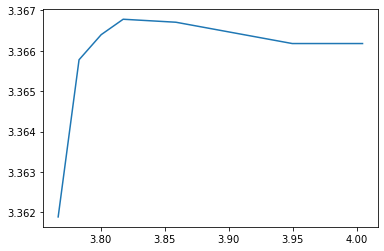

In [97]:
import matplotlib.pyplot as plt
plt.plot(times, iter_costs)

In [ ]:
traj_pgd.end_time()

In [ ]:
len(init_values)
ndim

In [ ]:
len(best_path)

In [ ]:
# dumb init
pts = np.squeeze(np.array([np.arctan(traj.value(it * traj.end_time() / 100)) for it in range(100)]))

In [ ]:
# np.hstack([pts, 0 * np.ones((pts.shape[0], 3 - pts.shape[1]))]).T
pts.shape

In [98]:
# # visualize path given trajectory
import visualization_utils as viz_utils
# viz_utils.draw_traj(visualizer.meshcat_cspace, traj, 100)
# viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj, 100, q_star=q_star)
# visualizer.animate_traj_s(traj, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_og, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_og, 100, q_star=q_star)
visualizer.animate_traj_s(traj_og, 100, 100)
viz_utils.draw_traj(visualizer.meshcat_cspace, traj_pgd, 100)
viz_utils.draw_nontc_traj(visualizer.meshcat_nontc, traj_pgd, 100, q_star=q_star)
visualizer.animate_traj_s(traj_pgd, 100, 100)

## Validating Paths?

In [100]:
# take a path
# calculate the q value at each point along the trajectory
# Sum all of them
def length_of_traj(traj):
    q_prev = np.array([0.3, 1.0])
    dist = 0
    for i in range(50):
        s = traj.value(traj.end_time()*i/50)
        q = Ratfk.ComputeQValue(s, q_star)
        dist += ((q - q_prev).dot(q - q_prev))**0.5
        q_prev = q
    return dist
new_len = length_of_traj(traj_pgd)
og_len = length_of_traj(traj_og)
print(new_len, og_len)

4.377200667606015 4.387048193241586


In [101]:
(og_len - new_len) / og_len

0.0022446814353992545

In [42]:
q_star

array([1., 1.])

In [49]:
traj_og.end_time()

3.0

In [50]:
traj_pgd.end_time()

3.0

In [56]:
iter_dist = 0
values = init_values
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [57]:
iter_dist

Array(3.3586519, dtype=float32)

In [58]:
iter_dist = 0
values = [best_rounded_result.GetSolution(x) for x in variables]
for v in range(len(best_path[1:-1])):
    iter_dist += distance_for_vertex(values[indices[v][0]:indices[v][1]])

In [59]:
iter_dist

Array(3.3597455, dtype=float32)

In [99]:
q_star

array([1., 1.])

## 7 DOF IIWA

In [5]:
#construct our robot
builder = DiagramBuilder()
plant, scene_graph = AddMultibodyPlantSceneGraph(builder, time_step=0.001)
parser = Parser(plant)

parser.package_map().Add("ciris_pgd", os.path.abspath(''))

directives_file = "/home/sgrg/rlg/SUPERUROP/ciris/models/iiwa14_sphere_collision_complex_scenario.dmd.yaml"
directives = LoadModelDirectives(directives_file)
models = ProcessModelDirectives(directives, plant, parser)


# oneDOF_iiwa_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/oneDOF_iiwa7_with_box_collision.sdf"
# with open(one|DOF_iiwa_file, 'r') as f:
#     oneDOF_iiwa_string = f.read()
# box_asset_file = "/home/sgrg/rlg/SUPERUROP/ciris/assets/box_small.urdf"
# with open(box_asset_file, 'r') as f:
#     box_asset_string = f.read()

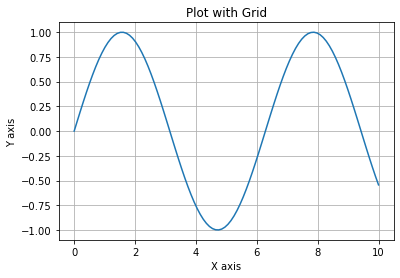

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Generate some data
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Create a plot
plt.plot(x, y)

# Add grid lines
plt.grid(True)

# Add labels and a title
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Plot with Grid')

# Show the plot
plt.show()

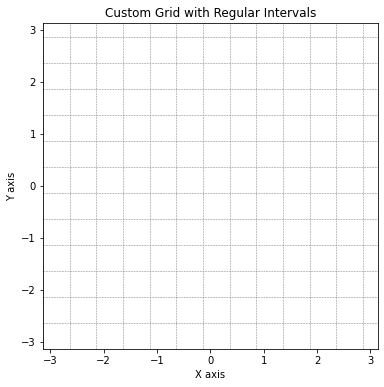

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Create a blank plot with a specific range for x and y
plt.figure(figsize=(6, 6))

# Define the grid lines
x_ticks = np.arange(-3.14, 3.14, 0.5)  # x-axis grid lines (adjusted for the plot range)
y_ticks = np.arange(-3.14, 3.14, 0.5)  # y-axis grid lines (adjusted for the plot range)

# Draw vertical lines (grid lines on the x-axis)
for x_tick in x_ticks:
    plt.axvline(x=x_tick, color='gray', linestyle='--', linewidth=0.5)

# Draw horizontal lines (grid lines on the y-axis)
for y_tick in y_ticks:
    plt.axhline(y=y_tick, color='gray', linestyle='--', linewidth=0.5)

# Set the x and y limits for the plot
plt.xlim(-3.14, 3.14)
plt.ylim(-3.14, 3.14)

# Add labels and title (optional)
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Custom Grid with Regular Intervals')

# Show the plot
plt.show()

<function matplotlib.pyplot.title(label, fontdict=None, loc=None, pad=None, *, y=None, **kwargs)>

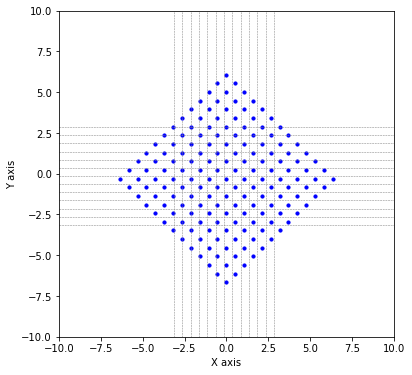

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Define the transformation function (example: a scaling and rotation)
def transform_point(x, y):
    # Example: scale by 1.5 and rotate by 45 degrees
    scale = 1.5
    angle = np.radians(45)  # Convert degrees to radians
    x_new = scale * (x * np.cos(angle) - y * np.sin(angle))
    y_new = scale * (x * np.sin(angle) + y * np.cos(angle))
    return x_new, y_new

# Create a blank plot with a specific range for x and y
plt.figure(figsize=(6, 6))

# Define the grid lines
x_ticks = np.arange(-3.14, 3.14, 0.5)  # x-axis grid lines
y_ticks = np.arange(-3.14, 3.14, 0.5)  # y-axis grid lines

# Draw vertical lines (grid lines on the x-axis)
for x_tick in x_ticks:
    plt.axvline(x=x_tick, color='gray', linestyle='--', linewidth=0.5)

# Draw horizontal lines (grid lines on the y-axis)
for y_tick in y_ticks:
    plt.axhline(y=y_tick, color='gray', linestyle='--', linewidth=0.5)

# Apply the transformation to each grid point and plot the transformed points
transformed_x = []
transformed_y = []

# Apply transformation to each grid point
for x_tick in x_ticks:
    for y_tick in y_ticks:
        x_new, y_new = transform_point(x_tick, y_tick)
        transformed_x.append(x_new)
        transformed_y.append(y_new)

# Plot the transformed points
plt.scatter(transformed_x, transformed_y, color='blue', s=10, label='Transformed Points')

# Set the x and y limits for the plot
plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Add labels and title
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title


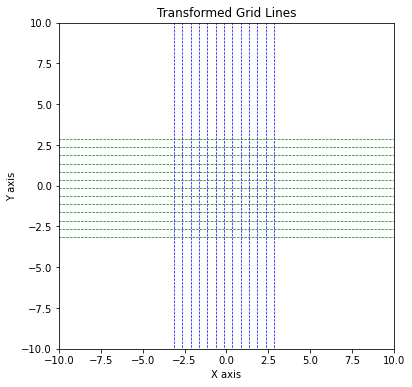

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Define the transformation function (example: scaling and rotation)
def transform_point(x, y):
    # Example transformation: scale by 1.5 and rotate by 45 degrees
    x_new = np.tan(x/2)
    y_new = np.tan(y/2)
    return x_new, y_new

# Create a blank plot with a specific range for x and y
plt.figure(figsize=(6, 6))

# Define the grid lines
x_ticks = np.arange(-3.14, 3.14, 0.5)  # x-axis grid lines
y_ticks = np.arange(-3.14, 3.14, 0.5)  # y-axis grid lines

# Plot transformed vertical grid lines
for x_tick in x_ticks:
    y_vals = np.linspace(-3.14, 3.14, 100)  # y-values for the vertical grid line
    x_transformed = np.full_like(y_vals, x_tick)  # All x values are the same for the vertical line
    y_transformed = [transform_point(x_tick, y)[1] for y in y_vals]  # Apply the transformation on y
    plt.plot(x_transformed, y_transformed, color='blue', linestyle='--', linewidth=0.7)

# Plot transformed horizontal grid lines
for y_tick in y_ticks:
    x_vals = np.linspace(-3.14, 3.14, 100)  # x-values for the horizontal grid line
    y_transformed = np.full_like(x_vals, y_tick)  # All y values are the same for the horizontal line
    x_transformed = [transform_point(x, y_tick)[0] for x in x_vals]  # Apply the transformation on x
    plt.plot(x_transformed, y_transformed, color='green', linestyle='--', linewidth=0.7)

# Set the x and y limits for the plot
plt.xlim(-10, 10)
plt.ylim(-10, 10)

# Add labels and title
plt.xlabel('X axis')
plt.ylabel('Y axis')
plt.title('Transformed Grid Lines')

# Show the plot
plt.show()


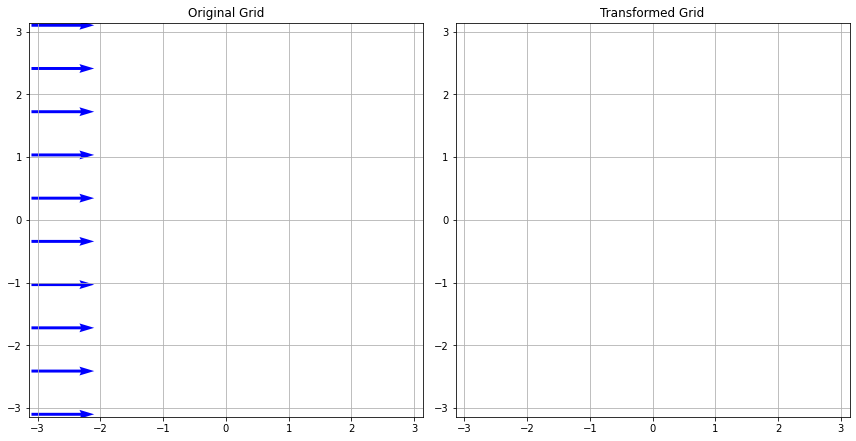

In [29]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Define the original grid
x = np.linspace(-3.1, 3,1, 10)  # 20 points along x-axis
y = np.linspace(-3.1, 3.1, 10)  # 20 points along y-axis
X, Y = np.meshgrid(x, y)    # Create the grid

# Step 2: Apply the transformation function
X_prime = np.tan(X/2)   # Transformed x-coordinates
Y_prime = np.tan(Y/2)    # Transformed y-coordinates

# Step 3: Plot original and transformed grids
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot the original grid
ax[0].set_title("Original Grid")
ax[0].quiver(X, Y, np.ones_like(X), np.zeros_like(X), angles="xy", scale_units="xy", scale=1, color='blue')
ax[0].set_xlim([-3.14, 3.14])
ax[0].set_ylim([-3.14, 3.14])
ax[0].set_aspect('equal')
ax[0].grid(True)

# Plot the transformed grid
ax[1].set_title("Transformed Grid")
ax[1].quiver(X_prime, Y_prime, np.ones_like(X_prime), np.zeros_like(Y_prime), angles="xy", scale_units="xy", scale=1, color='red')
ax[1].set_xlim([-3.14, 3.14])
ax[1].set_ylim([-3.14, 3.14])
ax[1].set_aspect('equal')
ax[1].grid(True)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Transformed grid in u-v space')

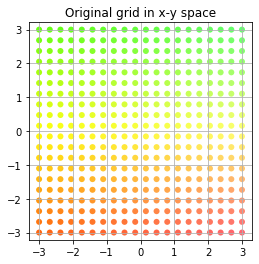

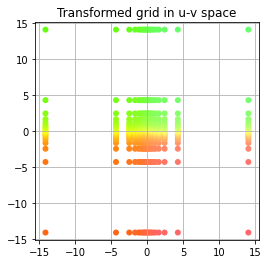

In [35]:
# Create a grid of points in x-y space 
xvals = np.linspace(-3, 3, 20)
yvals = np.linspace(-3, 3, 20)
xygrid = np.column_stack([[x, y] for x in xvals for y in yvals])

# Apply linear transform
# a = np.column_stack([[2, 1], [-1, 1]])
uvals = np.tan(xvals / 2)
vvals = np.tan(yvals / 2)
uvgrid = np.column_stack([[u, v] for u in uvals for v in vvals])
# uvgrid = np.dot(a, xygrid)

# Plot original and transformed grid points

# This function assigns a unique color based on position
def colorizer(x, y):
    """
    Map x-y coordinates to a rgb color
    """
    r = min(1, 1-y/5)
    g = min(1, 1+y/5)
    b = 1/4 + x/16
    return (r, g, b)

# Original version
#colorizer = lambda x, y: (1/2-y/6, 1/2+y/6, 1/2+x/8)

# Map grid coordinates to colors
colors = list(map(colorizer, xygrid[0], xygrid[1]))

# Plot x-y grid points 
plt.figure(figsize=(4, 4), facecolor="w")
plt.scatter(xygrid[0], xygrid[1], s=36, c=colors, edgecolor="none")
# Set axis limits
plt.grid(True)
plt.axis("equal")
plt.title("Original grid in x-y space")
# uncomment to save plot
#plt.savefig("../figures/grid-original.png", dpi=150)
#plt.savefig("../figures/grid-original-small.png", dpi=75)

# Plot transformed grid points
plt.figure(figsize=(4, 4), facecolor="w")
plt.scatter(uvgrid[0], uvgrid[1], s=36, c=colors, edgecolor="none")
plt.grid(True)
plt.axis("equal")
plt.title("Transformed grid in u-v space")
# uncomment to save plot
#plt.savefig("../figures/grid-transformed.png", dpi=150)
#plt.savefig("../figures/grid-transformed-small.png", dpi=75)

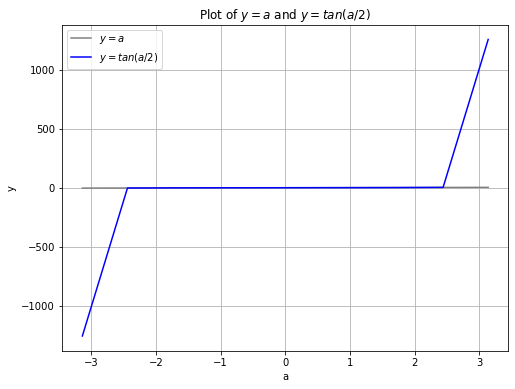

In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Define the values of 'a'
a_values = np.linspace(-3.14, 3.14, 10)

# Calculate y = a for each value of 'a'
y_line = a_values

# Calculate y = tan(a/2) for each value of 'a'
y_tan = np.tan(a_values / 2)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot y = a in gray
plt.plot(a_values, y_line, color='gray', label='$y = a$')

# Plot y = tan(a/2) in blue
plt.plot(a_values, y_tan, color='blue', label='$y = tan(a/2)$')

# Adding labels and title
plt.title("Plot of $y = a$ and $y = tan(a/2)$")
plt.xlabel("a")
plt.ylabel("y")
# plt.axhline(0, color='black',linewidth=0.5)
# plt.axvline(0, color='black',linewidth=0.5)

# Show the legend
plt.legend()

# Show the grid
plt.grid(True)

# Show the plot
plt.show()


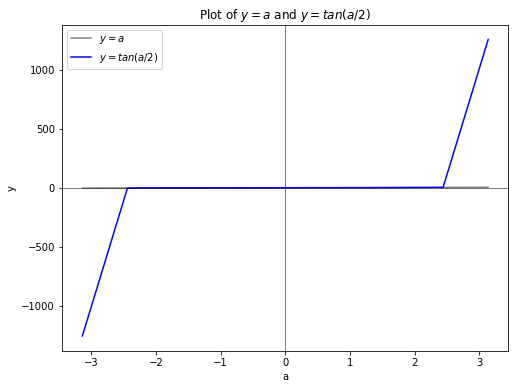

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Define the values of 'a'
a_values = np.linspace(-3.14, 3.14, 10)

# Calculate y = a for each value of 'a'
y_line = a_values

# Calculate y = tan(a/2) for each value of 'a'
y_tan = np.tan(a_values / 2)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot y = a in gray
plt.plot(a_values, y_line, color='gray', label='$y = a$')

# Plot y = tan(a/2) in blue
plt.plot(a_values, y_tan, color='blue', label='$y = tan(a/2)$')

# Adding labels and title
plt.title("Plot of $y = a$ and $y = tan(a/2)$")
plt.xlabel("a")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.5)
plt.axvline(0, color='black', linewidth=0.5)

# Show the legend
plt.legend()

# Turn off the grid
plt.grid(False)

# Show the plot
plt.show()


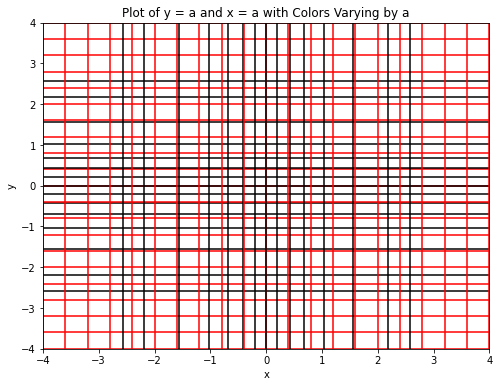

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

# Define the range of a from -4 to 4 (inclusive)
a_values = np.linspace(-4, 4, 21)  # 10 values between -4 and 4

# Define the range of x-axis and y-axis (from -4 to 4)
x_values = np.linspace(-4, 4, 21)
y_values = np.linspace(-4, 4, 21)

# Create a colormap (e.g., 'viridis', 'plasma', etc.)
# colors = [(0, "#0000ff"), (0.5, "#000080"), (1, "#ff0000")]
# cmap = cm.RdBu  # You can choose other colormaps like 'plasma', 'inferno', 'coolwarm'
# cmap = LinearSegmentedColormap.from_list("custom_RdBu", colors)

# Normalize the a_values to map them to the colormap
norm = plt.Normalize(vmin=np.min(a_values), vmax=np.max(a_values))

# Plot each line y = a for each a in a_values
plt.figure(figsize=(8, 6))

for a in a_values:
    # Choose a color from the colormap based on the value of a
#     color = cmap(norm(a))
    
    # Plot the horizontal line y = a (varying color)
    plt.plot(x_values, np.full_like(x_values, a), color="red")
    
    # Plot the horizontal line y = tan(a/2) (varying color)
    plt.plot(x_values, np.full_like(x_values, np.tan(a/2)), color="black")

# Plot vertical lines
for a in a_values:
    # Choose a color from the colormap based on the value of a
#     color = cmap(norm(a))
    
    # Plot the vertical line x = a (varying color)
    plt.plot(np.full_like(y_values, a), y_values, color="red")
    
    # Plot the vertical line x = tan(a/2) (varying color)
    plt.plot(np.full_like(y_values, np.tan(a/2)), y_values, color="black")

# Set labels and title
plt.title('Plot of y = a and x = a with Colors Varying by a')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(False)

# Set axis limits
plt.xlim(-4, 4)  # Set x-axis limits
plt.ylim(-4, 4)  # Set y-axis limits

# Show the plot
plt.show()

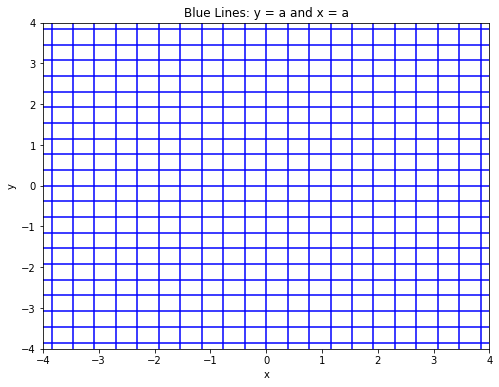

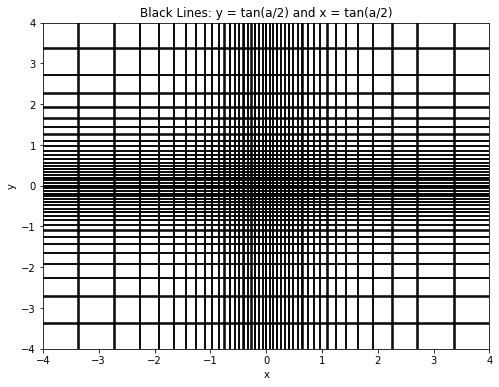

TypeError: return arrays must be of ArrayType

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Define the range of a from -4 to 4 (inclusive)
a_values = np.linspace(-20, 20, 105)  # 21 values between -4 and 4

# Define the range of x-axis and y-axis (from -4 to 4)
x_values = np.linspace(-20, 20, 105)
y_values = np.linspace(-20, 20, 105)

# First plot: Blue lines (both horizontal and vertical)
plt.figure(figsize=(8, 6))

# Plot the horizontal blue lines (y = a)
for a in a_values:
    plt.plot(x_values, np.full_like(x_values, a), color="blue")
    
# Plot the vertical blue lines (x = a)
for a in a_values:
    plt.plot(np.full_like(y_values, a), y_values, color="blue")

# Set labels and title for the first plot
plt.title('Blue Lines: y = a and x = a')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(False)

# Set axis limits
plt.xlim(-4, 4)
plt.ylim(-4, 4)

# Show the first plot
plt.show()

# Second plot: Black lines (both horizontal and vertical)
plt.figure(figsize=(8, 6))

# Plot the horizontal black lines (y = tan(a/2))
for a in a_values:
    plt.plot(x_values, np.full_like(x_values, np.tan(a/2)), color="black")

# Plot the vertical black lines (x = tan(a/2))
for a in a_values:
    plt.plot(np.full_like(y_values, np.tan(a/2)), y_values, color="black")

# Set labels and title for the second plot
plt.title('Black Lines: y = tan(a/2) and x = tan(a/2)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(False)

# Set axis limits
plt.xlim(-4, 4)
plt.ylim(-4, 4)

# Show the second plot
plt.show()

for a in a_values:
    plt.plot(x_values, np.full_like(x_values, 2 * np.arctan(a, 1)), color="black")

# Plot the vertical black lines (x = tan(a/2))
for a in a_values:
    plt.plot(np.full_like(y_values, 2 * np.arctan(a, 1)), y_values, color="black")

# Set labels and title for the second plot
plt.title('Black Lines: y = tan(a/2) and x = tan(a/2)')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(False)

# Set axis limits
plt.xlim(-20, 20)
plt.ylim(-20, 20)

# Show the second plot
plt.show()


/tmp/ipykernel_17064/1532350106.py:16: RuntimeWarning: divide by zero encountered in divide
  y_values = x_values / a
/tmp/ipykernel_17064/1532350106.py:19: RuntimeWarning: divide by zero encountered in divide
  y_values = 2 * np.arctan2(x_values, np.ones(x_values.shape)) / a


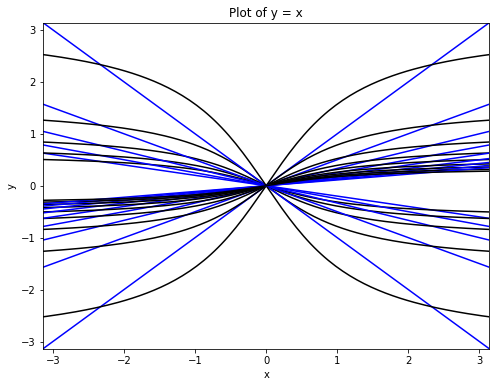

In [7]:

import matplotlib.pyplot as plt

# Define the x-values (e.g., from -10 to 10)
x_values = np.linspace(-10, 10, 400)  # 400 points between -10 and 10
plt.figure(figsize=(8, 6))


# for a in range(-5, 6):
#     y_values = a * x_values
#     plt.plot(x_values, y_values, label=f"{a}", color="blue")

#     y_values = 2 * a * np.atan(x_values, np.ones(x_values.shape))
#     plt.plot(x_values, y_values, label=f"{a}", color="black")

for a in range(-5, 10):
    y_values = x_values / a
    plt.plot(x_values, y_values, label=f"{a}", color="blue")

    y_values = 2 * np.arctan2(x_values, np.ones(x_values.shape)) / a
    plt.plot(x_values, y_values, label=f"{a}", color="black")
    
# # Define the y-values as y = x
# y_values = x_values  # Since y = x

# # Create the plot
# plt.plot(x_values, y_values, label="y = x", color="blue")

# x_values = np.linspace(-10, 10, 400)  # 400 points between -10 and 10

# # Define the y-values as y = x
# y_values = 2 * x_values  # Since y = x

# plt.plot(x_values, y_values, label="y = x", color="blue")

# # Define the y-values as y = x
# y_values = 0.5 * x_values  # Since y = x

# plt.plot(x_values, y_values, label="y = x", color="blue")

# y_values = np.tan(x_values / 2)  # Since y = x

# plt.plot(x_values, y_values, label="y = x", color="black")

# x_values = np.linspace(-10, 10, 400)  # 400 points between -10 and 10

# # Define the y-values as y = x
# y_values = 2 * np.tan(x_values / 2)  # Since y = x

# plt.plot(x_values, y_values, label="y = x", color="black")

# # Define the y-values as y = x
# y_values = 0.5 * np.tan(x_values / 2)  # Since y = x

# plt.plot(x_values, y_values, label="y = x", color="black")

# Add labels and title
plt.title("Plot of y = x")
plt.xlabel("x")
plt.ylabel("y")

# Set grid and limits
plt.grid(False)
plt.xlim(-3.14, 3.14)
plt.ylim(-3.14, 3.14)

# Show the plot
# plt.axhline(0, color='black',linewidth=1)  # Add the x-axis
# plt.axvline(0, color='black',linewidth=1)  # Add the y-axis
# plt.legend()

plt.show()

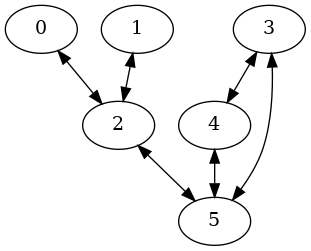

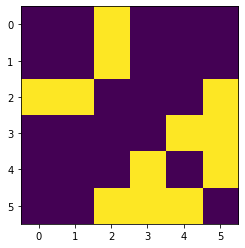

Graph has 1 connected components.


In [97]:
from pydrake.all import LoadIrisRegionsYamlFile
regions = list(LoadIrisRegionsYamlFile("/home/sgrg/rlg/SUPERUROP/ciris/104/connected_regions.yaml").values())
from util import notebook_plot_connectivity
notebook_plot_connectivity(regions, plot_dot=True, plot_adj_mat=True)

In [98]:
regions